# ECON 470 Homework 3.2
## Claire Hamilton

In [1]:
# Load packages

suppressPackageStartupMessages({
  library(tidyverse)
})

library(broom)
library(dplyr)
library(tibble)

In [2]:
# Check data

ma.full <- read_csv("../data/output/ma-full.csv", show_col_types = FALSE)

# glimpse(ma.full)

# Summarize the Data

## Question 1

In [3]:
q1 <- ma.full %>%
filter(!is.na(Star_Rating)) %>%
mutate(market_share = avg_enrollment / avg_eligibles) %>%
group_by(year) %>%
summarize(
    'Mean Star Rating' = round(mean(Star_Rating, na.rm = TRUE), 2),
    'Mean Enrollment' = round(mean(avg_enrollment, na.rm = TRUE), 2),
    'Mean Market Share' = round(mean(market_share, na.rm = TRUE), 4),
    'Plan Count' = n()
    )

q1

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010,2.97,346.99,0.0125,59579
2011,3.26,388.31,0.0151,55249
2012,3.36,410.65,0.0166,58169
2013,3.55,406.73,0.0163,64174
2014,3.81,451.11,0.0179,58636
2015,3.96,482.57,0.0193,60819


Star ratings, mean enrollments, and mean market shares tend to increase over time.

## Question 2

In [4]:
q2 <- ma.full %>%
filter(is.na(Star_Rating)) %>%
mutate(market_share = avg_enrollment / avg_eligibles) %>%
group_by(year) %>%
summarize(
    'Mean Enrollment' = round(mean(avg_enrollment, na.rm = TRUE), 2),
    'Mean Market Share' = round(mean(market_share, na.rm = TRUE), 4),
    'Plan Count' = n()
    )

q2

year,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<int>
2010,107.34,0.0092,48643
2011,167.90,0.0132,12754
2012,172.73,0.0119,9077
2013,213.50,0.0174,3661
2014,257.60,0.0158,3708
2015,314.21,0.0087,4680


The plans without a star rating tend to have lower average enrollments and market share compared to plans with a star rating. 

## Question 3

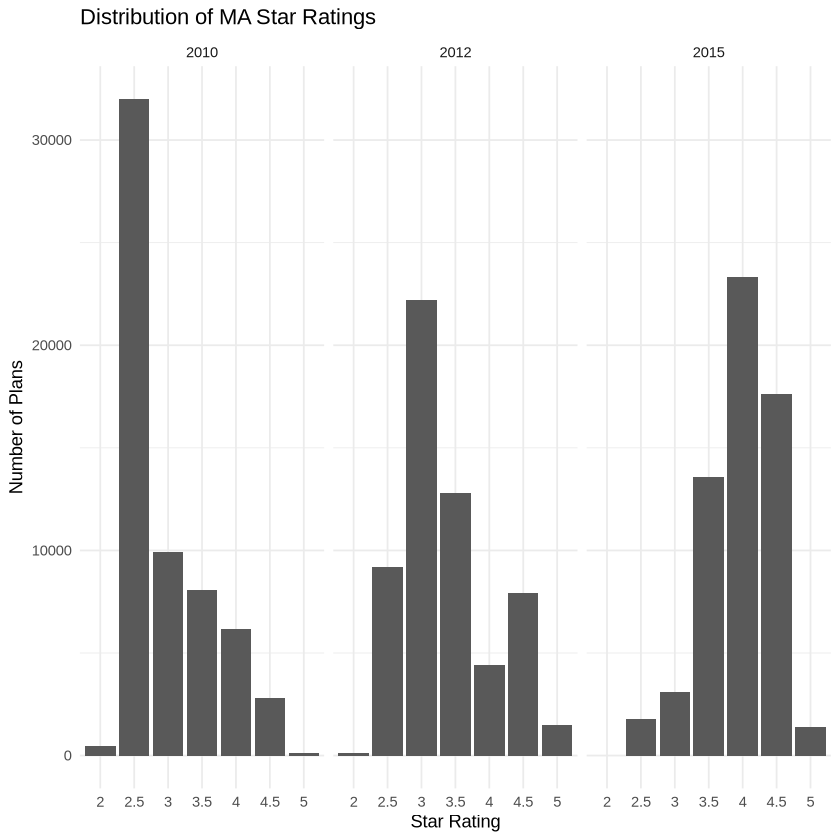

In [5]:
# Question 3

# Filter

stars_dist <- ma.full %>%
  filter(
    year %in% c(2010, 2012, 2015),
    !is.na(Star_Rating)
  )

# Bar graph

ggplot(stars_dist, aes(x = factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~year) +
  labs(
    title = "Distribution of MA Star Ratings",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal()

The distribution of star ratings has shifted to the right over time, meaning plans received higher star ratings (on average) in later years.

## Question 4

In [19]:
# Indicator variables

ma.full <- ma.full %>%
  mutate(
    market_share = avg_enrollment / avg_enrolled
  )

ma.full <- ma.full %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45p = as.integer(Star_Rating >= 4.5)
  )

ma.full <- ma.full %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45p = as.integer(Star_Rating >= 4.5)
  )

reg_2010 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2010))

reg_2011 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2011))

reg_2012 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2012))

reg_2013 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2013))

reg_2014 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2014))

reg_2015 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2015))

suppressPackageStartupMessages(library(stargazer))

stargazer(reg_2010, reg_2011, reg_2012, reg_2013, reg_2014, reg_2015,
          type = "text",
          column.labels = c("2010","2011","2012","2013","2014","2015"),
          covariate.labels = c("3 Stars","3.5 Stars","4 Stars","4.5+ Stars"),
          dep.var.labels = "Market Share",
          omit.stat = c("f","ser"))


                               Dependent variable:                   
             --------------------------------------------------------
                                   Market Share                      
               2010      2011      2012      2013     2014     2015  
                (1)       (2)       (3)      (4)      (5)      (6)   
---------------------------------------------------------------------
3 Stars      0.013***  0.035***  0.031***  0.062*** 0.027*** 0.027***
              (0.002)   (0.002)   (0.003)  (0.003)  (0.006)  (0.005) 
                                                                     
3.5 Stars      0.001   0.019***  0.013***  0.038*** 0.027*** 0.039***
              (0.002)   (0.003)   (0.003)  (0.003)  (0.006)  (0.004) 
                                                                     
4 Stars       -0.004*    0.003   -0.025*** 0.017***  0.007   0.011***
              (0.002)   (0.003)   (0.004)  (0.003)  (0.006)  (0.004) 
                   

# Estimate ATEs

## Question 5

In [15]:
# Question 5

data.2010 <- read.csv("../data/output/data-2010.csv")

data_cleaned <- data.2010 %>%
  mutate(
    raw_score = rowMeans(
      as.matrix(select(., breastcancer_screen:ttyt_available)),
      na.rm = TRUE
    ),
    star_from_raw = floor(raw_score * 2 + 0.5) / 2,
    rounded_up = (star_from_raw > floor(raw_score * 2) / 2)
  )

rounded_up_table <- data_cleaned %>%
  filter(star_from_raw %in% c(3, 3.5, 4, 4.5, 5)) %>%
  group_by(star_from_raw) %>%
  summarize(
    num_plans_rounded_up = sum(rounded_up, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  complete(star_from_raw = c(3, 3.5, 4, 4.5, 5),
           fill = list(num_plans_rounded_up = 0)) %>%
  arrange(star_from_raw) %>%
  rename(
    `Star Rating` = star_from_raw,
    `Plans Rounded Up` = num_plans_rounded_up
  )

rounded_up_table

Star Rating,Plans Rounded Up
<dbl>,<int>
3.0,4425
3.5,4605
4.0,5518
4.5,1095
5.0,30


## Question 6

In [8]:
data_cleaned <- data_cleaned %>%
  mutate(
    market_share = avg_enrollment / avg_enrolled
  )

star30 <- lm(
  market_share ~ treat + score,
  data = (data_cleaned %>%
            filter(raw_score >= (3.0 - 0.125),
                   raw_score <= (3.0 + 0.125),
                   Star_Rating %in% c(2.5, 3.0)) %>%
            mutate(
              treat = as.integer(raw_score >= 3.0),
              score = raw_score - 3.0
            ))
)

star35 <- lm(
  market_share ~ treat + score,
  data = (data_cleaned %>%
            filter(raw_score >= (3.5 - 0.125),
                   raw_score <= (3.5 + 0.125),
                   Star_Rating %in% c(3.0, 3.5)) %>%
            mutate(
              treat = as.integer(raw_score >= 3.5),
              score = raw_score - 3.5
            ))
)

rd_table <- bind_rows(
  tidy(star30) %>%
    filter(term == "treat") %>%
    mutate(
      Cutoff = "3.0 (3 vs 2.5)"
    ),

  tidy(star35) %>%
    filter(term == "treat") %>%
    mutate(
      Cutoff = "3.5 (3.5 vs 3)"
    )
) %>%
  select(Cutoff,
         Estimate = estimate,
         `Standard Error` = std.error,
         `p-value` = p.value)

rd_table

Cutoff,Estimate,Standard Error,p-value
<chr>,<dbl>,<dbl>,<dbl>
3.0 (3 vs 2.5),0.005672583,0.01046120,5.877038e-01
3.5 (3.5 vs 3),-0.051602810,0.01000886,2.805231e-07


## Question 7

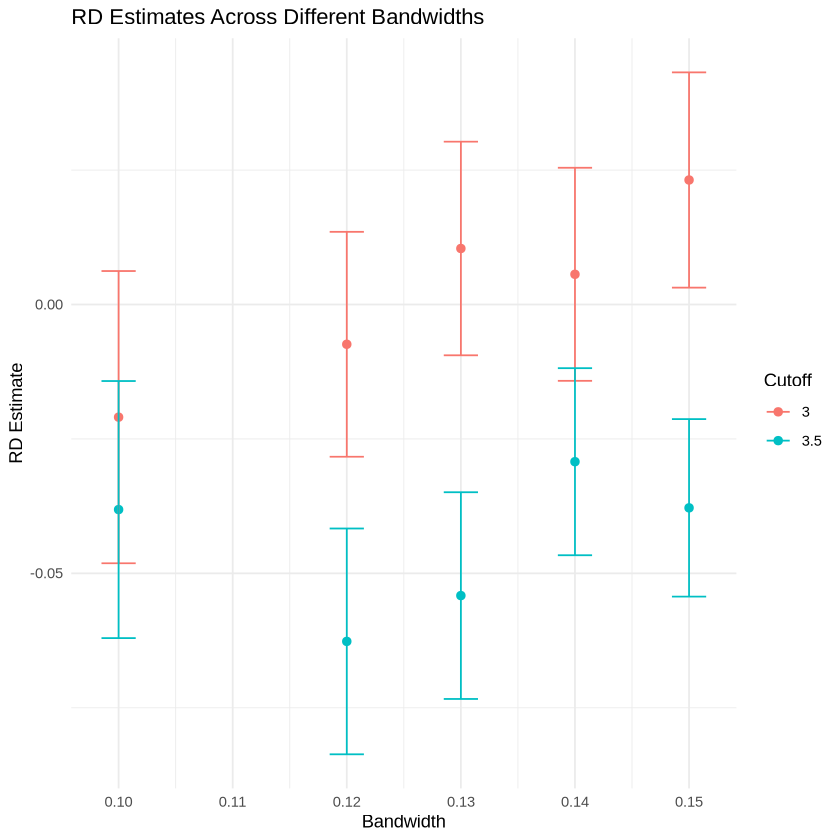

In [9]:
estimate_rd <- function(data, cutoff, bw) {

  rd <- data %>%
    filter(raw_score >= cutoff - bw,
           raw_score <= cutoff + bw) %>%
    filter(
      (cutoff == 3.0 & Star_Rating %in% c(2.5, 3.0)) |
      (cutoff == 3.5 & Star_Rating %in% c(3.0, 3.5))
    ) %>%
    mutate(
      treat = as.integer(raw_score >= cutoff),
      score = raw_score - cutoff
    )

  model <- lm(market_share ~ treat + score, data = rd)

  tibble(
    cutoff = cutoff,
    bandwidth = bw,
    estimate = coef(model)["treat"],
    se = summary(model)$coefficients["treat", "Std. Error"]
  )
}

bandwidths <- c(0.10, 0.12, 0.13, 0.14, 0.15)
cutoffs <- c(3.0, 3.5)

rd_results <- expand.grid(
  cutoff = cutoffs,
  bandwidth = bandwidths
) %>%
  rowwise() %>%
  do(estimate_rd(data_cleaned, .$cutoff, .$bandwidth)) %>%
  ungroup() %>%
  mutate(
    ci_low = estimate - 1.96 * se,
    ci_high = estimate + 1.96 * se
  )

ggplot(rd_results, aes(x = bandwidth, y = estimate, color = factor(cutoff))) +
  geom_point(size = 2) +
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), width = 0.003) +
  labs(
    title = "RD Estimates Across Different Bandwidths",
    x = "Bandwidth",
    y = "RD Estimate",
    color = "Cutoff"
  ) +
  theme_minimal()

My results are somewhat sensitive to the choice of bandwidth, tending to increase slightly as the bandwidth increases. The effect of receiving a 3-star rating on enrollments is slightly negative for a bandwidth of 0.1, but increases as the bandwidth increases, showing a positive relationship at bandwidths 0.13 and higher. The effect of receiving a 3.5 star rating is negative for all bandwidth values, but fluctuates slightly. 

## Question 8

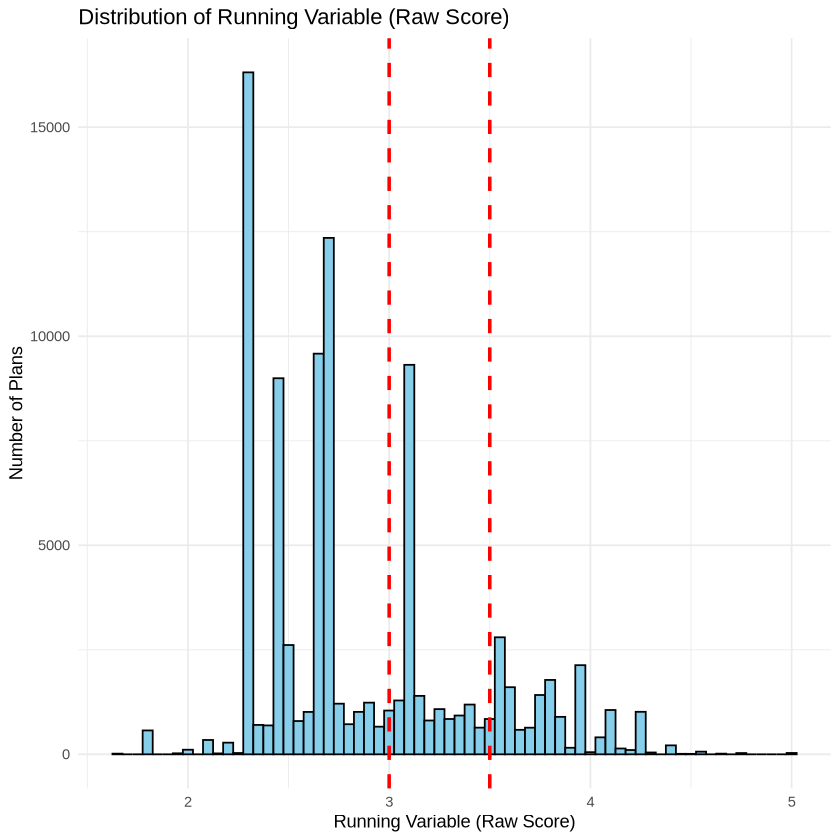

In [18]:
# Question 8

ggplot(data_cleaned %>% filter(is.finite(raw_score)), aes(x = raw_score)) +
  geom_histogram(binwidth = 0.05, color = "black", fill = "skyblue") +

  geom_vline(xintercept = c(3.0, 3.5),
             linetype = "dashed",
             color = "red",
             linewidth = 1) +

  labs(
    title = "Distribution of Running Variable (Raw Score)",
    x = "Running Variable (Raw Score)",
    y = "Number of Plans"
  ) +

  theme_minimal()

The distrubution of the running variable does not seem to change meaningfully before vs. after the 3.0 and 3.5 thresholds. There is no clear spike immediately to the right of the thresholds, so there is not strong evidence that contracts manipulate the running variable.

## Question 9

In [11]:
# Create indicators
data_cleaned <- data_cleaned %>%
  mutate(
    HMO = as.integer(grepl("HMO", plan_type)),
    PartD = as.integer(partd == "Yes")
  )

# RD balance-test function 
balance_rd <- function(data, cutoff, outcome, bw = 0.125) {

  rd <- data %>%
    filter(raw_score >= cutoff - bw,
           raw_score <= cutoff + bw) %>%
    filter(
      (cutoff == 3.0 & Star_Rating %in% c(2.5, 3.0)) |
      (cutoff == 3.5 & Star_Rating %in% c(3.0, 3.5))
    ) %>%
    mutate(
      treat = as.integer(raw_score >= cutoff),
      score = raw_score - cutoff
    )

  model <- lm(as.formula(paste(outcome, "~ treat + score")), data = rd)

  tidy(model) %>%
    filter(term == "treat") %>%
    transmute(
      Outcome = outcome,
      Cutoff = cutoff,
      Estimate = estimate,
      `Std. Error` = std.error,
      `p-value` = p.value,
    )
}

# Table
balance_table <- bind_rows(
  balance_rd(data_cleaned, 3.0, "HMO"),
  balance_rd(data_cleaned, 3.5, "HMO"),
  balance_rd(data_cleaned, 3.0, "PartD"),
  balance_rd(data_cleaned, 3.5, "PartD")
) %>%
  mutate(
    Cutoff = paste0(Cutoff, " stars")
  )

balance_table

Outcome,Cutoff,Estimate,Std. Error,p-value
<chr>,<chr>,<dbl>,<dbl>,<dbl>
HMO,3 stars,-0.25313139,0.02798669,2.052827e-19
HMO,3.5 stars,-0.61496149,0.03142092,3.879232e-82
PartD,3 stars,-0.03874186,0.01738055,2.585237e-02
PartD,3.5 stars,0.03247998,0.02019898,1.079004e-01


The statistically significant negative coefficients indicate that plans just above the thresholds are less likely to be HMOs than plans just below the thresholds. However, Part D status shows little difference across the cutoffs, with small and mostly insignificant estimates. This suggests some differences in HMO status near the thresholds but not much evidence of differences in Part D status.

## Question 10

Based on my current analysis, increasing a star rating has little to no effect on enrollments at the 3-star threshold but a small negative effect at the 3.5-star threshold. The RD estimate at 3 stars is close to zero and not statistically significant, while the estimate at 3.5 stars is negative and significant. The results are somewhat similar across bandwidths, though the effect of receiving 3 stars increases slightly as bandwidth increases, and it is statistically significant when using a bandwidth of 0.15. There is no clear evidence of manipulation of the running variable, though plans just above the threshold are less likely to be HMOs.